## Building Chatbots With Multiple Tools Using LangGraph

Aim:
- Create a chatbot with tool capabilities from ArXiv, Wikipedia search and other functions

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [6]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wikipedia.name)

wikipedia


In [7]:
wikipedia.invoke("What is Machine Learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [8]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_Agent"

In [9]:
## Custom FUnction
def multiply(a: int, b: int) -> int:
    """Multiplies two integers.
    
    Args:
        a: The first integer.
        b: The second integer.
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds two integers.
    
    Args:
        a: The first integer.
        b: The second integer.
    """
    return a + b

def divide(a: int, b: int) -> int:
    """Divides two integers.
    
    Args:
        a: The first integer.
        b: The second integer.
    """
    if b == 0:
        return "Cannot divide by zero"
    return a / b

In [10]:
## Tavily Tool
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

/var/folders/kt/hhlws00n53502tnyykkz678r0000gn/T/ipykernel_1679/794941660.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [11]:
tavily.invoke("What is the latest news in AI?")

[{'title': 'The latest AI news we announced in January - Google Blog',
  'url': 'https://blog.google/innovation-and-ai/products/google-ai-updates-january-2026/',
  'content': '## Bullet points\n\n This article recaps Google\'s AI news from January, highlighting advancements in personal intelligence and various applications.\n Gemini app now connects to Google apps, offering personalized help; it\'s opt-in and available in beta.\n Gmail gets AI tools like "Help me write" for free; paid subscribers get advanced features like Proofread.\n Chrome\'s new features, powered by Gemini 3, include "auto browse" for complex tasks and image transformation.\n Google introduced AI learning tools with Khan Academy and Oxford, plus practice tests in the Gemini app.\n\n#### Explore other styles:\n\nYour browser does not support the audio element. [...] We introduced the next evolution of AI in Gmail, built for the Gemini era. AI tools like Help me write, AI Overviews and suggested replies with personal

In [12]:
## Combine all the tools in the list
tools = [arxiv, wikipedia, tavily, add, multiply, divide]

In [13]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10b669160>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10b669e80>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [14]:
llm_with_tools = llm.bind_tools(tools)

In [15]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([
    HumanMessage(content="What is the latest news in AI?")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xngjwcpmg', 'function': {'arguments': '{"query":"latest news in AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 748, 'total_tokens': 769, 'completion_time': 0.056158751, 'completion_tokens_details': None, 'prompt_time': 0.049031321, 'prompt_tokens_details': None, 'queue_time': 0.0485544, 'total_time': 0.105190072}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4bae-d14b-7991-9ff1-06d5cf38ba9b-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest news in AI'}, 'id': 'xngjwcpmg', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 748, 'output_tokens': 21, 'total_tokens': 769})

In [16]:
llm_with_tools.invoke([
    HumanMessage(content="What is the latest news in AI?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest news in AI'},
  'id': '861hq8jmh',
  'type': 'tool_call'}]

In [17]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [18]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

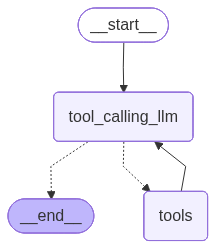

In [19]:
## Node Function

def tool_calling_llm(state: State) -> State:
    return {"messages": llm_with_tools.invoke(state["messages"])}

## Graph Construction
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
messages = graph.invoke({
    "messages": HumanMessage(content="What is the latest news in AI?")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the latest news in AI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (dejaphg88)
 Call ID: dejaphg88
  Args:
    query: latest news in AI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "Date: September 7, 2025 Summary: Dutch chip-equipment giant ASML is set to become the largest shareholder in European AI startup Mistral AI by leading its €1.7 billion funding round with a €1.3 billion investment. The capital infusion values Mistral at €10 billion, making it the most valuable AI company in Europe. ASML will likely gain a board seat and could integrate Mistral’s AI and analytics capabilities into its li

In [21]:
messages = graph.invoke({
    "messages": HumanMessage(content="What is the latest news in AI? What is 5 plus 5 and the multiple 10 to the result")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the latest news in AI? What is 5 plus 5 and the multiple 10 to the result
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (qq43h028g)
 Call ID: qq43h028g
  Args:
    query: latest news in AI
  add (pkm461nx6)
 Call ID: pkm461nx6
  Args:
    a: 5
    b: 5
  multiply (jy8xxxat8)
 Call ID: jy8xxxat8
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business ...", "url": "https://www.artificialintelligence-news.com/", "content": "Entertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### C

## Agent Memory

Lets Implement Agents with Memory

In [22]:
messages = graph.invoke({
    "messages": HumanMessage(content="What is 5 plus 8?")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 8?
================================== Ai Message ==================================
Tool Calls:
  add (8nck00bt2)
 Call ID: 8nck00bt2
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The answer is 13.


In [23]:
messages = [HumanMessage(content="Divide that by 5")]
messages = graph.invoke({
    "messages": messages})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (b6078d5nr)
 Call ID: b6078d5nr
  Args:
    a: 0
    b: 5
================================= Tool Message =================================
Name: divide

0.0
================================== Ai Message ==================================

I need a number to divide by 5. Please provide the number. I will then divide it by 5.


## MemorySaver

- LangGraph can use a checkpointer to save the graph state after each step
- This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update
- One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state
- All we need to do is simply compile the graph with a checkpointer, and our graph has memory

In [24]:
## Node Function

def tool_calling_llm(state: State) -> State:
    return {"messages": llm_with_tools.invoke(state["messages"])}

## Graph Construction
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

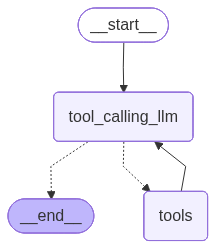

In [25]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [26]:
# Specify the Thread

config = {"configurable": {"thread_id": "1"}}

messages = graph_memory.invoke({
    "messages": HumanMessage(content="What is 5 plus 8?")}, config=config)

for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is 5 plus 8?
================================== Ai Message ==================================
Tool Calls:
  add (0z3h65bjd)
 Call ID: 0z3h65bjd
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The answer is 13.


In [27]:
messages = graph_memory.invoke({
    "messages": HumanMessage(content="Divide that by 5")}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 8?
================================== Ai Message ==================================
Tool Calls:
  add (0z3h65bjd)
 Call ID: 0z3h65bjd
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The answer is 13.
================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (jtn0hvs1j)
 Call ID: jtn0hvs1j
  Args:
    a: 13
    b: 5
================================= Tool Message =================================
Name: divide

2.6
================================== Ai Message ==================================

The answer is 2.6.
